In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.preprocessing import LabelEncoder


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/part_3_nlp_sequence_modeling/customer_support_text_classification.csv')

# Preview dataset
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


# Task 1: Dataset Understanding

Number of records: 1500

Number of columns: 6

Target classes:
- neutral
- positive
- negative


Sample customer messages:
1. I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
2. I need information about the payment process.
3. The refund process was fast and convenient. I appreciate the quick response.
4. My refund is still pending and this experience is frustrating. My ticket number is 33927.
5. Please tell me how to update my account details.


Average text length: 12.722666666666667


sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64 



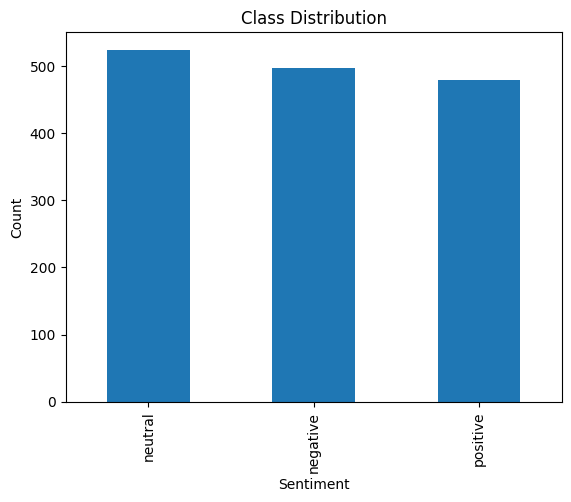

In [5]:
# Number of records

print(f"Number of records: {df.shape[0]}\n")
print(f"Number of columns: {df.shape[1]}\n")


# Target labels/classes

print("Target classes:")
for label in df['sentiment_label'].unique():
    print(f"- {label}")
print("\n")


# Sample text records

print("Sample customer messages:")
for i, msg in enumerate(df['customer_message'].head(5), 1):
    print(f"{i}. {msg}")
print("\n")


# Average text length
def get_text_length(text):
    words = str(text).split()
    return len(words)

df['text_length'] = df['customer_message'].apply(get_text_length)

print("Average text length:", df['text_length'].mean())
print("\n")


# Class distribution

class_counts = df['sentiment_label'].value_counts()
print(class_counts,"\n")

class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


# Task 2 &3: Text Preprocessing and Text Vectorization

In [6]:
# Define preprocessing function

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                     # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)     # remove symbols/numbers
    words = text.split()                        # tokenization
    words = [word for word in words if word not in stop_words]   # remove stopwords
    return ' '.join(words)

In [7]:
# Apply Preprocessing

df['clean_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [8]:
# Convert text to sequences

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [9]:
# Padding

max_length = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [10]:


print("Vocabulary size:", len(tokenizer.word_index))

print("\nSample cleaned text:")
print(df['clean_text'].iloc[0])

print("\nConverted sequence:")
print(sequences[0])

print("\nPadded sequence:")
print(padded_sequences[0])

Vocabulary size: 147

Sample cleaned text:
need information payment process ticket number please respond soon possible

Converted sequence:
[15, 105, 65, 19, 2, 3, 4, 5, 6, 7]

Padded sequence:
[ 15 105  65  19   2   3   4   5   6   7   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


### Why text must be converted into vectors
Machine learning models cannot understand raw text directly because they perform mathematical calculations on numerical data. Text vectorization converts words into numbers so the model can process patterns, relationships, and make predictions.

# Task 4: Baseline Model

In [11]:
# Prepare Data

X = df['clean_text']
y = df['sentiment_label']

# Train-test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#TF-IDF vectorization

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#Train Logistic Regression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

# Predicion

y_pred = baseline_model.predict(X_test_tfidf)

# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



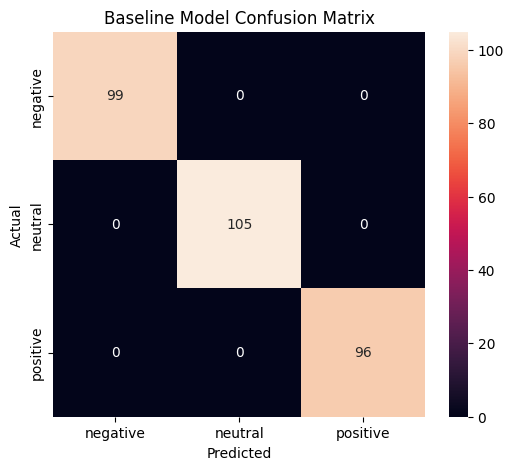

In [12]:
# Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=baseline_model.classes_,
            yticklabels=baseline_model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Model Confusion Matrix")
plt.savefig('model_evaluation.png')
plt.show()


# Task 5: Sequence Model or Conceptual Architecture

In [13]:
# Encode labels

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['sentiment_label'])

print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [14]:
# Train-test split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded_sequences,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [15]:
# Build LSTM model

vocab_size = 5000
embedding_dim = 64
max_length = 50

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
# Compile

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [17]:
# Convert labels to numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['sentiment_label'])

# Split padded sequences for LSTM
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded_sequences,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [18]:
# Train

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.3594 - loss: 1.1003 - val_accuracy: 0.3375 - val_loss: 1.1018
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.3552 - loss: 1.0998 - val_accuracy: 0.3375 - val_loss: 1.1025
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3427 - loss: 1.0990 - val_accuracy: 0.3375 - val_loss: 1.1012
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.3323 - loss: 1.1000 - val_accuracy: 0.3375 - val_loss: 1.1040
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3479 - loss: 1.0968 - val_accuracy: 0.3375 - val_loss: 1.1014
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.3594 - loss: 1.0982 - val_accuracy: 0.3375 - val_loss: 1.1020
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.3531 - loss: 1.0985 - val_accuracy: 0.3375 - val_loss: 1.1001
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.3406 - loss: 1.0987 - val_accuracy: 0.3042 

In [19]:
# Evaluate

loss, accuracy = lstm_model.evaluate(X_test_seq, y_test_seq)

print("LSTM Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3500 - loss: 1.0979
LSTM Test Accuracy: 0.3499999940395355


# Task 6: Attention and Transformer Reflection



### Why RNNs struggle with long-term dependencies
RNNs process text one word at a time and pass information from one step to the next. When sequences become long, important information from earlier words can gradually fade or be lost. This makes it difficult for RNNs to remember long-term context.

### How LSTMs help with memory
LSTMs improve RNNs by using memory cells and gates that control what information should be kept, updated, or forgotten. This helps the model retain important information for longer sequences and improves performance on text tasks.

### What attention solves in sequence-to-sequence tasks
Attention allows the model to focus on the most relevant parts of the input sequence instead of relying only on the final hidden state. This improves tasks like translation, summarization, and text generation because the model can directly access important words when making predictions.

### Why transformers are important in modern NLP and Generative AI
Transformers use attention mechanisms to process all words in parallel instead of one at a time. This makes training faster and allows the model to understand long-range relationships better. Modern NLP systems such as ChatGPT, BERT, and other generative AI models are based on transformer architecture.

In [20]:
# sample prediction

pred_probs = lstm_model.predict(X_test_seq)
pred_classes = pred_probs.argmax(axis=1)

pred_labels = label_encoder.inverse_transform(pred_classes)
true_labels = label_encoder.inverse_transform(y_test_seq)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step


In [22]:
sample_file = 'sample_predictions.txt'

with open(sample_file, 'w') as f:
    for i in range(10):
        original_text = df['customer_message'].iloc[i]

        f.write(f"Input Text: {original_text}\n")
        f.write(f"Actual Label: {true_labels[i]}\n")
        f.write(f"Predicted Label: {pred_labels[i]}\n")
        f.write("-" * 50 + "\n")

